# Purpose

Show that removing cell type profiles decreases performance of specific cell type-related GO terms

In [3]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from scipy.stats import ttest_rel
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve, auc
from scipy.stats import spearmanr

In [4]:
def load_ct_removal(tissue:str, path_to_boot:str)->pd.DataFrame:
    """Loads the ct removal experimental results in a dataframe for a given removal of a tissue (or cell type)

    Args:
        tissue (str): usually a cell type that has been removed in the ct removal experiment
        path_to_boot (str, optional): Path to ct removal experiment directory. Defaults to "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/ctRemovalExperiment/boot_100_0327":str.
    """
    def get_diff(merged):
        merged['diff']=merged['exp']-merged['cont']
        return merged
    def get_diff_deg(merged):
        merged['diff_deg']=merged['exp_deg']-merged['cont_deg']
        return merged
    lo_boots = np.array(os.listdir(path_to_boot), dtype=int)
    lo_boots = np.sort(lo_boots)[0:-1]
    lo_tissue_cont_paths = [f"{path_to_boot}/{boot}/EGAD/{tissue}_removed_control_EGAD.csv" for boot in lo_boots]
    lo_tissue_exp_paths = [f"{path_to_boot}/{boot}/EGAD/{tissue}_removed_experiment_EGAD.csv" for boot in lo_boots]
 
    lo_tissue_cont_dfs = [pd.read_csv(path) for path in lo_tissue_cont_paths]
    lo_tissue_exp_dfs = [pd.read_csv(path) for path in lo_tissue_exp_paths]
    
    lo_cont_with_boots = []
    for tissue_df, boot_value in zip(lo_tissue_cont_dfs, lo_boots):
        tissue_df['boot'] = boot_value
        lo_cont_with_boots.append(tissue_df)
    cont_boots = pd.concat(lo_cont_with_boots, axis = 0)
    
    lo_exp_with_boots = []
    for tissue_df, boot_value in zip(lo_tissue_exp_dfs, lo_boots):
        tissue_df['boot'] = boot_value
        lo_exp_with_boots.append(tissue_df)
    exp_boots = pd.concat(lo_exp_with_boots, axis = 0)
    
    exp_boots.rename(columns={'auc':'exp'}, inplace = True)
    cont_boots.rename(columns={'auc':'cont'}, inplace = True)
    
    exp_boots = exp_boots.reset_index()
    cont_boots = cont_boots.reset_index()
    
    merged = pd.merge(left = exp_boots, right = cont_boots, left_on = ['index', 'boot'], right_on = ['index', 'boot'])
    # print(merged.head())
    merged = merged.loc[:,['index', 'exp', 'degree_null_auc_x',  'cont', "degree_null_auc_y", 'boot']]

    
    merged.set_index('index', inplace = True)
    
    merged.rename(columns = {"degree_null_auc_x":'exp_deg',
                             "degree_null_auc_y":'cont_deg'}, inplace=True)
    merged = get_diff(merged=merged)
    merged = get_diff_deg(merged=merged)
    return merged

def get_con_exp_stats(merged:pd.DataFrame)->pd.DataFrame():
    """
    For each GO term, perform a paired t-test using the simulation bootstraps as instances

    Args:
        merged (pd.DataFrame): a melted dataframe containing performances of GO terms from this instance of a CT removal experiment

    Returns:
        pd.DataFrame: Dataframe with stats for each GO term
    """
    
    all_gos = merged.index.unique()

    lo_dfs = []
    for GO in all_gos:
        go_df = merged[merged.index == GO]

        
        # calculat effect size
        effect_size = go_df.loc[:,'diff'].mean()
        
        # Perform a paired t-test
        t_statistic, p_value = ttest_rel(go_df.loc[:,'cont'], go_df.loc[:,'exp'], alternative='greater')
        
        df_row = pd.DataFrame([{"GO":GO, 'pval':p_value, 't':t_statistic, 'effect':effect_size, 'cont':go_df['cont'].mean(), 'exp':go_df['exp'].mean(), 'exp_deg':go_df['exp_deg'].mean()}])
        lo_dfs.append(df_row)
        
    df_concat = pd.concat(lo_dfs, axis = 0)
    
    return df_concat

def add_metadata_to_stats(df_stats:pd.DataFrame, GO_curations:pd.DataFrame) -> pd.DataFrame:
    """Adds GO term metadata to the statistics

    Args:
        df_stats (df of stats for each GO term): df of stats for each GO term
        GO_curations (pd.DataFrame): Df of GO Curations
    Returns:
        pd.DataFrame: Stats with metadata
    """

    concat_meta = pd.merge(left = df_stats, right = GO_curations, left_on="GO", right_on='id')
    concat_with_meta = concat_meta.loc[:,['id', 'cont','exp','effect','exp_deg','pval','name', 'def', 'CTAffiliated','BrainAffiliated', 'PBMCAffiliated']]
    return concat_with_meta

def call_ct_related_go_terms(concat_with_meta:pd.DataFrame)->pd.DataFrame:
    """Add metadata about the ranks of our GO terms based on the statistics

    Args:
        concat_with_meta (pd.DataFrame): df of GO terms with T-stat scores

    Returns:
        pd.DataFrame: 
    """
    def make_r_rank(ranked_terms):
        """Helper function to get rank based on effect size"""
        ranked_terms = ranked_terms.sort_values('effect', ascending=False).reset_index(drop=True).reset_index()
        ranked_terms.rename(columns = {'index': 'r-rank'}, inplace=True)
        return ranked_terms
    def make_p_r_rank(ranked_terms):
        """Helper function to get rank based on pval"""

        ranked_terms = ranked_terms.sort_values('pval', ascending=False).reset_index(drop=True).reset_index()
        ranked_terms.rename(columns = {'index': 'r_pval_rank'}, inplace=True)
        return ranked_terms
    def make_deg_rrank(ranked_terms):
        """Helper function to get rank based on node degree"""
        ranked_terms = ranked_terms.sort_values('exp_deg', ascending=True).reset_index(drop=True).reset_index()
        ranked_terms.rename(columns = {'index': 'rank_exp_deg'}, inplace=True)
        return ranked_terms
    
    concat_with_meta = concat_with_meta.sort_values(by = 'effect')
    concat_with_meta = concat_with_meta.reset_index(drop = True)
    concat_with_meta['rank'] = concat_with_meta.index
    ranked_terms = concat_with_meta.copy()
    
    ranked_terms = make_r_rank(ranked_terms=ranked_terms)
    ranked_terms = make_p_r_rank(ranked_terms=ranked_terms)
    ranked_terms = make_deg_rrank(ranked_terms=ranked_terms)
    
    ranked_terms['logp']=np.log(ranked_terms.pval)
    ranked_terms.sort_values('effect', inplace=True)
    

    return ranked_terms


def get_ranked_terms(path_to_boot:str, tissue:str, GO_curations:pd.DataFrame)->tuple:
    """Wrapper function to do stats on a ct removal experiment and to get the top ranked terms


    Args:
        path_to_boot (str): path_to_ct removal directory
        tissue (str): current cell type that is removed
        GO_curations (pd.DataFrame): Df of GO curations

    Returns:
        pd.DataFrame: Dataframe that tells us what GO terms decrease the most when we remove this cell type
    """
    merged = load_ct_removal(path_to_boot=path_to_boot, tissue=tissue)
    df_stats = get_con_exp_stats(merged=merged)
    concat_with_meta = add_metadata_to_stats(df_stats = df_stats, GO_curations=GO_curations)
    ranked_terms = call_ct_related_go_terms(concat_with_meta=concat_with_meta)
    return concat_with_meta, ranked_terms

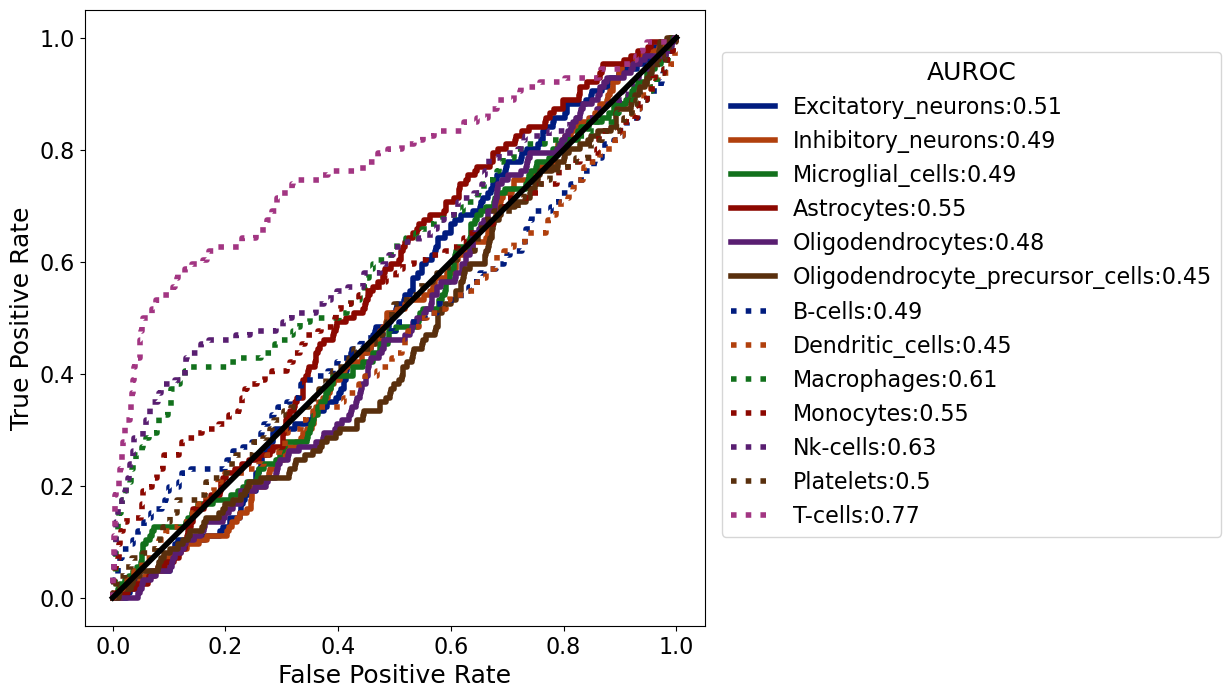

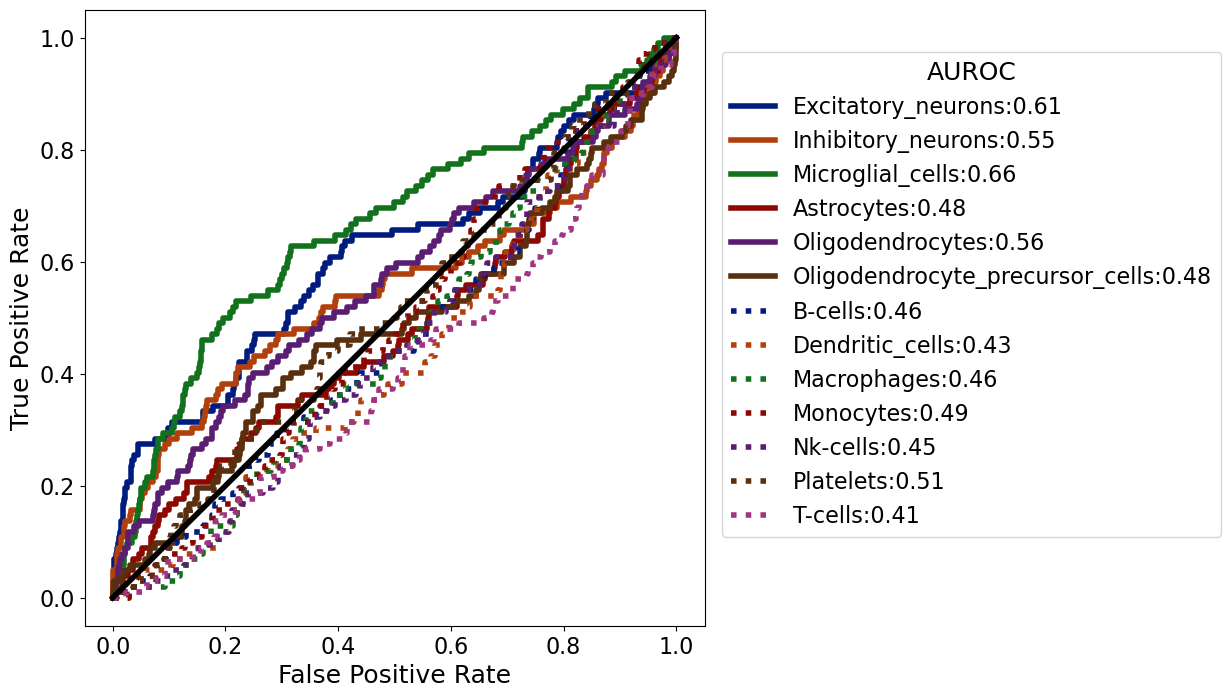

In [4]:
def make_auroc_for_go_aff(path_to_boot, lo_cts, label_col, predictor_col, cmap, stylemap, ax, GO_curations) -> dict:
    """Makes a ROC graph overaid for each ct.
    
    Also returns a dictionary where keys are ct from a ct removal experiment, and values are the AUC

    Args:
        path_to_boot (_type_): _description_
        lo_cts (_type_): _description_
        label_col (_type_): _description_
        predictor_col (_type_): _description_
        cmap (_type_): _description_
        stylemap (_type_): _description_
        ax (_type_): _description_
        GO_curations (_type_): _description_

    Returns:
        dict: _description_
    """
    
    def plot_auc(ranked_terms, predictor_colname, label_colname, color, ax, style, ct):
        # r-rank classification
        predicted_scores = ranked_terms[predictor_colname] 
        labels =  ranked_terms.loc[:,label_colname]=="T"
        # Compute ROC curve
        fpr, tpr, thresholds = roc_curve(labels, predicted_scores)
        roc_auc = auc(x=fpr, y =tpr)
        ax.plot(fpr, tpr, color=color, lw=4, label=f"{ct}:{roc_auc.round(2)}", linestyle = style)
        
    def calc_auc(ranked_terms, predictor_colname, label_colname):
        # r-rank classification
        predicted_scores = ranked_terms[predictor_colname] 
        labels =  ranked_terms.loc[:,label_colname]=="T"
        # Compute ROC curve
        fpr, tpr, thresholds = roc_curve(labels, predicted_scores)
        roc_auc = auc(x=fpr, y =tpr)
        return roc_auc
        
            
    # get the ranked calls for each cell type
    lo_ranked_dfs = []
    for ct in lo_cts:
        concat_with_meta, ranked_df =  get_ranked_terms(path_to_boot = path_to_boot, GO_curations=GO_curations, tissue = ct)
        lo_ranked_dfs.append(ranked_df)
    
    dic_aurocs = {}
    # get auroc for each ranked_df
    for i, ranked_df in enumerate(lo_ranked_dfs):
        ct = lo_cts[i]
        color = cmap.get(ct)
        style = stylemap.get(ct)
        
        # Plot ROC Curve on graph
        plot_auc(ranked_terms=ranked_df,
            predictor_colname=predictor_col,
            label_colname=label_col,
            color = color ,
            ax = ax,
            style = style,
            ct=ct)
        # Calc AUC
        roc_auc = calc_auc(ranked_terms=ranked_df,
            predictor_colname=predictor_col,
            label_colname=label_col)
        # Save AUC for Later
        dic_aurocs[ct] = roc_auc
        
        
    # Add diagonal
    ax.plot([0, 1], [0, 1], color='black', lw=4, linestyle='-',)
    ax.set_ylabel("True Positive Rate", fontsize=18)
    ax.set_xlabel("False Positive Rate", fontsize=18)
    # Axises and title
    # ax.set_title(f"Predicting {label_col}-Related Terms", fontsize=26)
    # Simplified way to set font size for both x and y tick labels
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontsize(16)

    ax.legend(bbox_to_anchor = (1.01, 0.95), title='AUROC', fontsize='16', title_fontsize='18')
    
    return dic_aurocs


def make_auroc(label_col)->dict:
    """Make an AUROC graph for CT removal experiments, where we are trying to predict GO terms in label_col
    Also, returns AUROCfor each ct removal experiment
    Args:
        label_col (str): One of BrainAffiliated, PBMCAffiliated, CTAffiliated
    """
    def make_cmap():
        lo_brain_cts =  ['Excitatory_neurons',
            'Inhibitory_neurons',
            'Microglial_cells',
            'Astrocytes',
            'Oligodendrocytes',
            'Oligodendrocyte_precursor_cells']
        palette = sns.color_palette('dark')
        cmap_brain = dict(zip(lo_brain_cts,palette))
        
        lo_pbmc_cts =["B-cells",
            "Dendritic_cells",
            "Macrophages",
            "Monocytes",
            "Nk-cells",
            "Platelets",
            "T-cells"]
        palette = sns.color_palette('dark')
        cmap_pbmc = dict(zip(lo_pbmc_cts,palette))
        cmap_brain.update(cmap_pbmc)
        return cmap_brain

    def make_stylemap():
        lo_brain_cts =  ['Excitatory_neurons',
            'Inhibitory_neurons',
            'Microglial_cells',
            'Astrocytes',
            'Oligodendrocytes',
            'Oligodendrocyte_precursor_cells']
        style = "-"
        stylemap_brain = dict(zip(lo_brain_cts,np.repeat(style, len(lo_brain_cts))))
        
        lo_pbmc_cts =["B-cells",
            "Dendritic_cells",
            "Macrophages",
            "Monocytes",
            "Nk-cells",
            "Platelets",
            "T-cells"]
        style = ":"
        stylemap_pbmc = dict(zip(lo_pbmc_cts,np.repeat(style, len(lo_pbmc_cts))))
        stylemap_brain.update(stylemap_pbmc)
        return stylemap_brain
        
    
    lo_cts = ['Excitatory_neurons',
          'Inhibitory_neurons',
          'Microglial_cells',
          'Astrocytes',
          'Oligodendrocytes',
          'Oligodendrocyte_precursor_cells',
          "B-cells",
          "Dendritic_cells",
          "Macrophages",
          "Monocytes",
          "Nk-cells",
          "Platelets",
          "T-cells"]
    # lo_cts = ['Excitatory_neurons']

    cmap = make_cmap()
    stylemap = make_stylemap()
    
    
    def load_metadata(path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/GOCurations.tsv")->pd.DataFrame:
        GO_curations = pd.read_csv(path, sep = "\t")
        return GO_curations
    
    GO_curations = load_metadata()

    fig, ax1 = plt.subplots(1,1, figsize = (8,8))
    
    dic_performance = make_auroc_for_go_aff(path_to_boot="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/ctRemovalExperiment/boot_100_0327",
                        lo_cts = lo_cts,
                        label_col=label_col,
                        predictor_col='r_pval_rank',
                        cmap = cmap,
                        stylemap=stylemap,
                        ax=ax1,
                        GO_curations = GO_curations)
    
    fig.savefig(f"figs/AUROC/AUROC_{label_col}.png", dpi=300, bbox_inches='tight',)
    return dic_performance
# Make plots for predicting PBMC affiliated GO term labels
# dic_pbmc_performance = make_auroc("PBMCAffiliated")
# Make plots for predicting Brain Affiliated GO term labels
dic_brain_performance = make_auroc("BrainAffiliated")


FileNotFoundError: [Errno 2] No such file or directory: 'figs/PRAUC/PRAUC_BrainAffiliated.png'

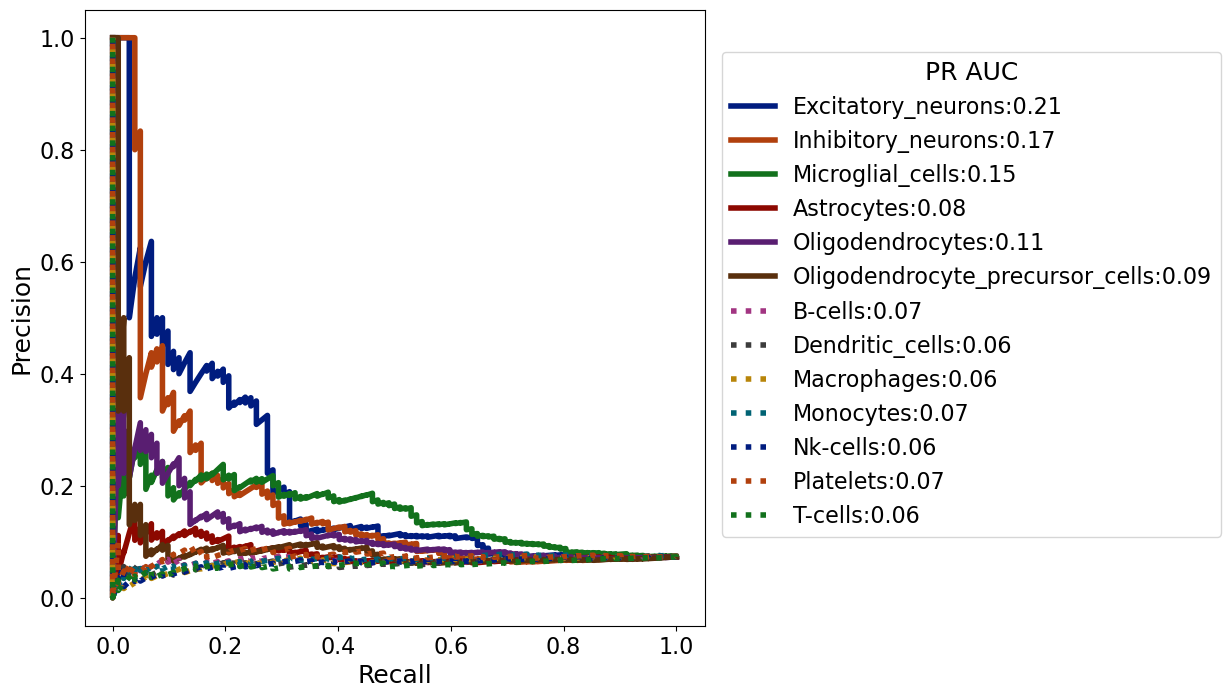

In [5]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def make_prauc_for_go_aff(path_to_boot, lo_cts, label_col, predictor_col, cmap, stylemap, ax, GO_curations) -> dict:
    """Makes a Precision-Recall AUC graph overlaid for each CT. Also returns PR AUCs."""
    
    def plot_prauc(ranked_terms, predictor_colname, label_colname, color, ax, style, ct):
        scores = ranked_terms[predictor_colname]
        labels = ranked_terms[label_colname] == "T"
        precision, recall, _ = precision_recall_curve(labels, scores)
        pr_auc = auc(recall, precision)
        ax.plot(recall, precision, color=color, lw=4, label=f"{ct}:{pr_auc:.2f}", linestyle=style)

    def calc_prauc(ranked_terms, predictor_colname, label_colname):
        scores = ranked_terms[predictor_colname]
        labels = ranked_terms[label_colname] == "T"
        precision, recall, _ = precision_recall_curve(labels, scores)
        return auc(recall, precision)

    dic_praucs = {}

    for ct in lo_cts:
        _, ranked_df = get_ranked_terms(path_to_boot=path_to_boot, tissue=ct, GO_curations=GO_curations)
        color = cmap.get(ct)
        style = stylemap.get(ct)

        plot_prauc(ranked_df, predictor_col, label_col, color, ax, style, ct)
        dic_praucs[ct] = calc_prauc(ranked_df, predictor_col, label_col)

    ax.set_ylabel("Precision", fontsize=18)
    ax.set_xlabel("Recall", fontsize=18)

    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontsize(16)

    ax.legend(bbox_to_anchor=(1.01, 0.95), title='PR AUC', fontsize=16, title_fontsize=18)

    return dic_praucs
def make_prauc(label_col: str) -> dict:
    """Make PR AUC graph for CT removal experiments. Returns PR AUCs per CT."""
    
    def make_cmap():
        brain_cts = ['Excitatory_neurons', 'Inhibitory_neurons', 'Microglial_cells',
                     'Astrocytes', 'Oligodendrocytes', 'Oligodendrocyte_precursor_cells']
        pbmc_cts = ["B-cells", "Dendritic_cells", "Macrophages",
                    "Monocytes", "Nk-cells", "Platelets", "T-cells"]
        all_cts = brain_cts + pbmc_cts
        colors = sns.color_palette('dark', len(all_cts))
        return dict(zip(all_cts, colors))

    def make_stylemap():
        brain_cts = ['Excitatory_neurons', 'Inhibitory_neurons', 'Microglial_cells',
                     'Astrocytes', 'Oligodendrocytes', 'Oligodendrocyte_precursor_cells']
        pbmc_cts = ["B-cells", "Dendritic_cells", "Macrophages",
                    "Monocytes", "Nk-cells", "Platelets", "T-cells"]
        return {ct: "-" if ct in brain_cts else ":" for ct in brain_cts + pbmc_cts}

    def load_metadata(path="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/preprocessing/preprocessGO_pipe/data/2024_march/data/GOCurations.tsv"):
        return pd.read_csv(path, sep="\t")

    lo_cts = ['Excitatory_neurons', 'Inhibitory_neurons', 'Microglial_cells',
              'Astrocytes', 'Oligodendrocytes', 'Oligodendrocyte_precursor_cells',
              "B-cells", "Dendritic_cells", "Macrophages", "Monocytes", "Nk-cells", "Platelets", "T-cells"]

    cmap = make_cmap()
    stylemap = make_stylemap()
    GO_curations = load_metadata()

    fig, ax1 = plt.subplots(figsize=(8, 8))

    dic_performance = make_prauc_for_go_aff(
        path_to_boot="/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/ctRemovalExperiment/boot_100_0327",
        lo_cts=lo_cts,
        label_col=label_col,
        predictor_col='r_pval_rank',  # or 'r-rank'
        cmap=cmap,
        stylemap=stylemap,
        ax=ax1,
        GO_curations=GO_curations
    )

    fig.savefig(f"figs/PRAUC/PRAUC_{label_col}.png", dpi=300, bbox_inches='tight')
    return dic_performance

dic_brain_performance = make_prauc("BrainAffiliated")

